In [19]:
import os
import shutil
import random
from PIL import Image, UnidentifiedImageError, ImageFile
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [2]:
# Allow loading incomplete images
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [3]:
# --- Paths ---
base_dir = r"D:\\Plants_Dataset"
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

In [4]:
# --- Step 0: Split dataset (Only run once!) ---
#After that, if you rerun, comment out the dataset-splitting section to avoid duplicate copies.
classes = ['Tomato', 'wheat']
random.seed(42)

# for cls in classes:
#     crop_folder = os.path.join(train_dir, cls)
#     for disease in os.listdir(crop_folder):
#         disease_path = os.path.join(crop_folder, disease)
#         if not os.path.isdir(disease_path):
#             continue

#         images = [os.path.join(disease_path, f) for f in os.listdir(disease_path)
#                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
#         random.shuffle(images)

#         total = len(images)
#         train_split = int(0.8 * total)
#         valid_split = int(0.9 * total)

#         splits = {
#             train_dir: images[:train_split],
#             valid_dir: images[train_split:valid_split],
#             test_dir: images[valid_split:]
#         }

#         for split_dir, file_list in splits.items():
#             target_dir = os.path.join(split_dir, cls, disease)
#             os.makedirs(target_dir, exist_ok=True)
#             for src in file_list:
#                 dst = os.path.join(target_dir, os.path.basename(src))
#                 shutil.move(src, dst)  # Move instead of copy to avoid duplication

# print("✅ Dataset split into train/valid/test folders with subfolders per disease.") 

In [5]:
# --- Step 1: PNG to JPG Converter ---
for base in [train_dir, valid_dir, test_dir]:
    for root, _, files in os.walk(base):
        for file in files:
            if file.endswith(".png"):
                png_path = os.path.join(root, file)
                jpg_path = os.path.splitext(png_path)[0] + ".jpg"
                try:
                    with Image.open(png_path) as img:
                        rgb_img = img.convert("RGB")
                        rgb_img.save(jpg_path)
                    os.remove(png_path)
                except Exception as e:
                    print(f"Failed to convert {png_path}: {e}")

# --- Step 2: Remove Corrupted Images ---
for base in [train_dir, valid_dir, test_dir]:
    for root, _, files in os.walk(base):
        for file in files:
            path = os.path.join(root, file)
            try:
                with Image.open(path) as img:
                    img.verify()
            except (UnidentifiedImageError, IOError, SyntaxError, OSError) as e:
                print(f"Removing corrupted file: {path} ({e})")
                os.remove(path)

In [6]:
# --- Step 3: Data Generators ---
batch_size = 32
img_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

valid_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    classes=classes,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = valid_test_datagen.flow_from_directory(
    valid_dir,
    classes=classes,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    test_dir,
    classes=classes,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 22057 images belonging to 2 classes.
Found 2759 images belonging to 2 classes.
Found 2767 images belonging to 2 classes.


In [7]:
# --- Step 4: CNN Model ---
model = Sequential([
    Input(shape=(224, 224, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,245,186 (84.86 MB)

 Trainable params: 22,245,186 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# --- Step 5: Callbacks ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
]

In [9]:
# --- Step 6: Train ---
epochs = 20
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=callbacks
)

model.save("final_model.keras")

C:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
690/690 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9309 - loss: 0.1702
Epoch 1: val_loss improved from inf to 0.04047, saving model to best_model.keras
690/690 ━━━━━━━━━━━━━━━━━━━━ 748s 1s/step - accuracy: 0.9309 - loss: 0.1701 - val_accuracy: 0.9866 - val_loss: 0.0405 - learning_rate: 1.0000e-04
Epoch 2/20
690/690 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.9877 - loss: 0.0349
Epoch 2: val_loss improved from 0.04047 to 0.01437, saving model to best_model.keras
690/690 ━━━━━━━━━━━━━━━━━━━━ 702s 1s/step - accuracy: 0.9877 - loss: 0.0349 - val_accuracy: 0.9946 - val_loss: 0.0144 - learning_rate: 1.0000e-04
Epoch 3/20
690/690 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.9907 - loss: 0.0309
Epoch 3: val_loss did not improve from 0.01437
690/690 ━━━━━━━━━━━━━━━━━━━━ 597s 865ms/step - accuracy: 0.9907 - loss: 0.0309 - val_accuracy: 0.9946 - val_loss: 0.0173 - learning_rate: 1.0000e-04
Epoch 4/20
690/690 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.9915 - loss: 0.02

In [10]:
# --- Step 7: Evaluate on Test Set ---
test_loss, test_acc = model.evaluate(test_generator)
print(f"\U0001F4CA Final Test Accuracy: {test_acc * 100:.2f}%")

87/87 ━━━━━━━━━━━━━━━━━━━━ 26s 299ms/step - accuracy: 0.9993 - loss: 0.0027
📊 Final Test Accuracy: 99.89%


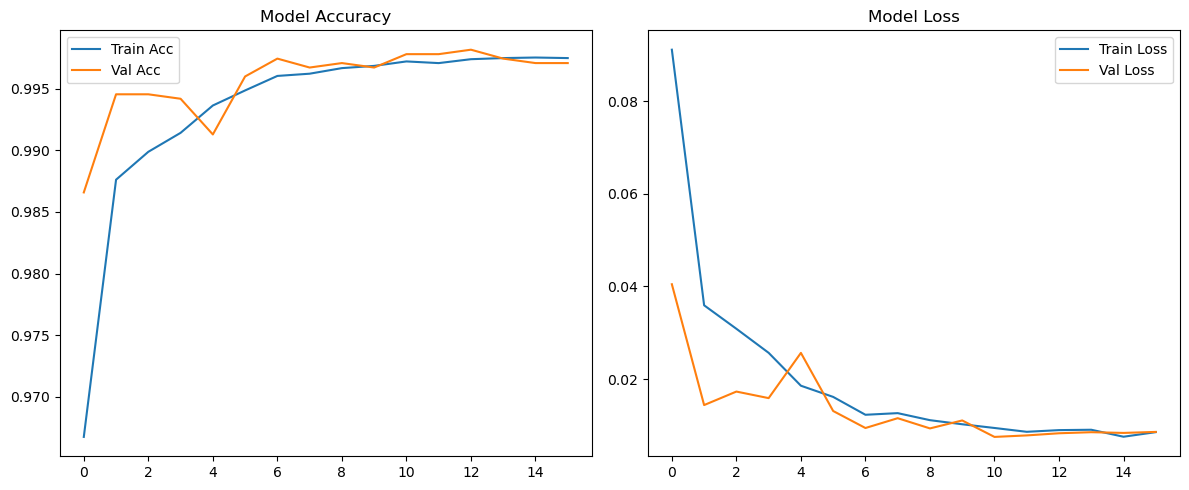

In [11]:
# --- Step 8: Plot Results ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.models import load_model
best_model = load_model("best_model.keras")

87/87 ━━━━━━━━━━━━━━━━━━━━ 30s 343ms/step


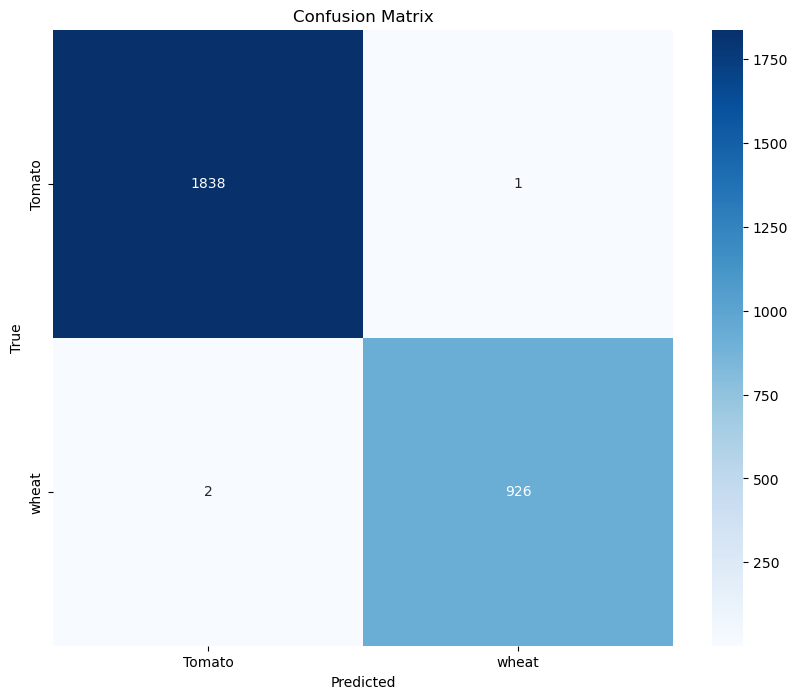


Classification Report:
              precision    recall  f1-score   support

      Tomato       1.00      1.00      1.00      1839
       wheat       1.00      1.00      1.00       928

    accuracy                           1.00      2767
   macro avg       1.00      1.00      1.00      2767
weighted avg       1.00      1.00      1.00      2767



In [20]:
# --- Step 9: Confusion Matrix & Classification Report ---
predictions = best_model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))